# Visualization :)

## Plotting TrackIR data:

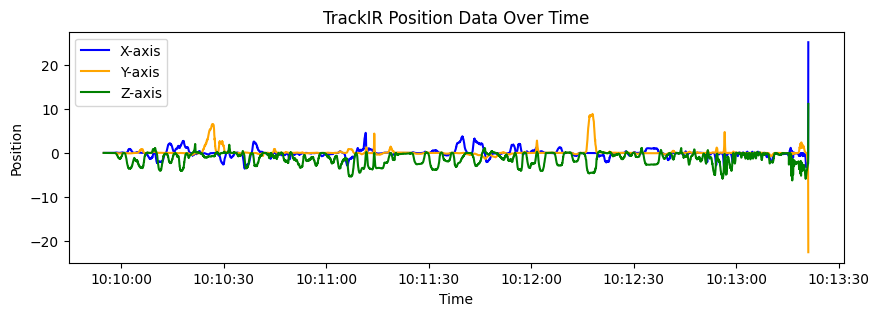

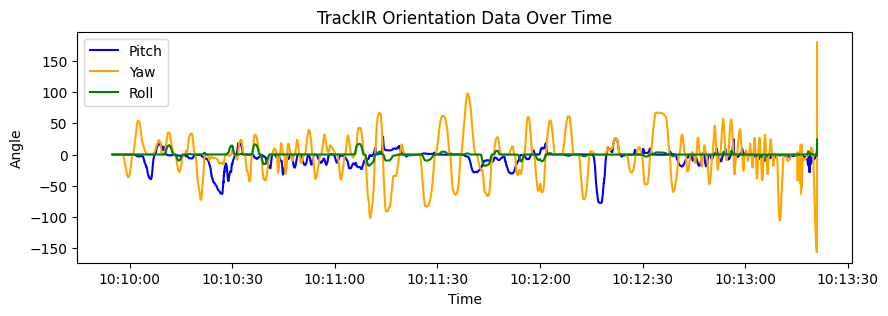

In [2]:
# Loading libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Reading SenseMat and TrackIR data:
sensemat_file_path = "Synched data\\20260422T120945_sensemat_synched.csv"
trackir_file_path = "Synched data\\20260422T120945_trackir_synched.csv"
sensemat_df = pd.read_csv(sensemat_file_path, sep=",")
trackir_df = pd.read_csv(trackir_file_path, sep=";")
# Convert Unix timestamps to datetime
trackir_df["Time"] = pd.to_datetime(trackir_df["Unix_Timestamp"], unit="s")

# Plotting the TrackIR data (position and orientation) in one cell
def plot_trackir_data(trackir_df):
    plt.figure(figsize=(10, 3))
    plt.plot(trackir_df["Time"], trackir_df["X"], label="X-axis", color="blue")
    plt.plot(trackir_df["Time"], trackir_df["Y"], label="Y-axis", color="orange")
    plt.plot(trackir_df["Time"], trackir_df["Z"], label="Z-axis", color="green")
    plt.title("TrackIR Position Data Over Time")
    plt.xlabel("Time")
    plt.ylabel("Position")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.plot(trackir_df["Time"], trackir_df["Pitch"], label="Pitch", color="blue")
    plt.plot(trackir_df["Time"], trackir_df["Yaw"], label="Yaw", color="orange")
    plt.plot(trackir_df["Time"], trackir_df["Roll"], label="Roll", color="green")
    plt.title("TrackIR Orientation Data Over Time")
    plt.xlabel("Time")
    plt.ylabel("Angle")
    plt.legend()
    plt.show()
plot_trackir_data(trackir_df)

## Method to retrieve TrackIR data recorded with the 'default'-profile 

In [3]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.integrate import cumulative_trapezoid

# ============================================================
# TrackIR default-profile inversion
# ============================================================

# Assumed dataframe columns:
# ['Unix_Timestamp', 'X', 'Y', 'Z', 'Pitch', 'Yaw', 'Roll']

# ------------------------------------------------------------
# PROFILE CURVES
# ------------------------------------------------------------
# Interpretation:
#   physical_head_motion  -> TrackIR_output
#
# We invert:
#   TrackIR_output -> estimated physical_head_motion
#
# Each pair:
#   (input_angle, output_value)
# ------------------------------------------------------------

profile = {

    'Yaw': np.array([
        [-49.7041, 6],
        [-30, 6],
        [-15, 6],
        [-7.39645, 4.10256],
        [-1, 0],
        [0, 0],
        [1, 0],
        [7.39645, 4.10256],
        [15, 6],
        [30, 6],
        [49.7041, 6]
    ]),

    'Pitch': np.array([
        [-49, 6],
        [-30, 6],
        [-22.4852, 6],
        [-6.50888, 3.58974],
        [-2.5, 0.5],
        [0, 0],
        [2.5, 0.5],
        [6.50888, 3.58974],
        [22.4852, 6],
        [30, 6],
        [49, 6]
    ]),

    'Roll': np.array([
        [-48.9105, 2],
        [-40, 2],
        [-30, 2],
        [-13.3136, 2],
        [-6.21302, 0],
        [0, 0],
        [6.21302, 0],
        [13.3136, 2],
        [30, 2],
        [40, 2],
        [48.9105, 2]
    ]),

    'X': np.array([
        [-48.9105, 2],
        [-40, 2],
        [-30, 2],
        [-20, 2],
        [-3, 2],
        [0, 0],
        [3, 2],
        [20, 2],
        [30, 2],
        [40, 2],
        [48.9105, 2]
    ]),

    'Y': np.array([
        [-49.7041, 4],
        [-40, 4],
        [-30, 4],
        [-19.5266, 4],
        [-2.5, 4],
        [0, 0],
        [2.5, 4],
        [19.5266, 4],
        [30, 4],
        [40, 4],
        [49.7041, 4]
    ]),

    'Z': np.array([
        [-49.4083, 2],
        [-40, 2],
        [-30, 2],
        [-20, 2],
        [-3, 2],
        [0, 0],
        [2, 2],
        [24, 2],
        [28.1065, 0],
        [40, 0],
        [48.8, 0]
    ])
}

# ============================================================
# BUILD TRUE FORWARD + INVERSE MAPPINGS
# ============================================================

inverse_maps = {}

for axis, pts in profile.items():

    x_real = pts[:, 0]
    gain = pts[:, 1]

    # integrate gain:
    # y_virtual(x) = integral gain dx

    y_virtual = cumulative_trapezoid(gain, x_real, initial=0)

    # center around zero
    zero_idx = np.argmin(np.abs(x_real))
    y_virtual -= y_virtual[zero_idx]

    # build inverse interpolation:
    # virtual -> real

    inverse_maps[axis] = interp1d(
        y_virtual,
        x_real,
        kind='linear',
        bounds_error=False,
        fill_value='extrapolate'
    )


# ============================================================
# APPLY INVERSE TRANSFORM
# ============================================================

def recover_true_motion(df):

    df_out = df.copy()

    for axis, inv_map in inverse_maps.items():

        if axis in df.columns:

            df_out[axis + '_Recovered'] = inv_map(df[axis].values)

    return df_out


# ============================================================
# USAGE
# ============================================================

# df = pd.read_csv("trackir.csv")

# df_corrected = recover_true_motion(df)

# Example:
# print(df_corrected[['Yaw', 'Yaw_Recovered']].head())

In [6]:
# Loading libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Reading SenseMat and TrackIR data:
sensemat_file_path = "Synched data\\20260422T120945_sensemat_synched.csv"
trackir_file_path = "Synched data\\20260422T120945_trackir_synched.csv"
sensemat_df = pd.read_csv(sensemat_file_path, sep=",")
trackir_df = pd.read_csv(trackir_file_path, sep=";")
# Convert Unix timestamps to datetime
trackir_df["Time"] = pd.to_datetime(trackir_df["Unix_Timestamp"], unit="s")
trackir_df_recovered = recover_true_motion(trackir_df)
trackir_df_recovered.describe()

,Unix_Timestamp,X,Y,Z,Pitch,Yaw,Roll,Time,Yaw_Recovered,Pitch_Recovered,Roll_Recovered,X_Recovered,Y_Recovered,Z_Recovered
count,8.244000e+03,8244.000000,8244.000000,8244.000000,8244.000000,8244.000000,8244.000000,8244,8244.000000,8244.000000,8244.000000,8244.000000,8244.000000,8244.000000
mean,1.776853e+09,-0.022424,0.166995,-1.252407,-5.224066,-2.271867,-0.319642,2026-04-22 10:11:38.036253696,-0.523901,-2.602609,-3.868056,-0.026372,0.076960,-1.197606
min,1.776853e+09,-3.565350,-22.460137,-6.220292,-77.598299,-156.628132,-18.323117,2026-04-22 10:09:54.972693920,-32.516594,-20.852472,-18.924869,-3.282675,-6.865034,-4.610146
25%,1.776853e+09,-0.222480,-0.040499,-2.224429,-7.334296,-14.594054,0.000000,2026-04-22 10:10:46.526808320,-7.688088,-5.781038,-6.213020,-0.222480,-0.020250,-2.224429
50%,1.776853e+09,-0.021825,0.000367,-0.817756,-1.148525,0.000000,0.000000,2026-04-22 10:11:38.012173312,-1.000000,-2.756019,-6.213020,-0.021825,0.000183,-0.817756
75%,1.776853e+09,0.067529,0.049761,-0.091470,0.025150,11.958482,0.000000,2026-04-22 10:12:29.632490240,6.829766,0.100599,-6.213020,0.067529,0.024880,-0.091470
max,1.776853e+09,25.040246,8.828850,11.082884,28.397434,180.000000,24.117777,2026-04-22 10:13:21.052361965,36.411905,10.591326,21.822199,14.020123,3.457213,6.541442
std,5.949861e+01,0.950677,1.059618,1.376301,13.106769,32.807542,4.146337,NaN,9.693444,5.179913,7.250333,0.891824,0.460963,1.254109


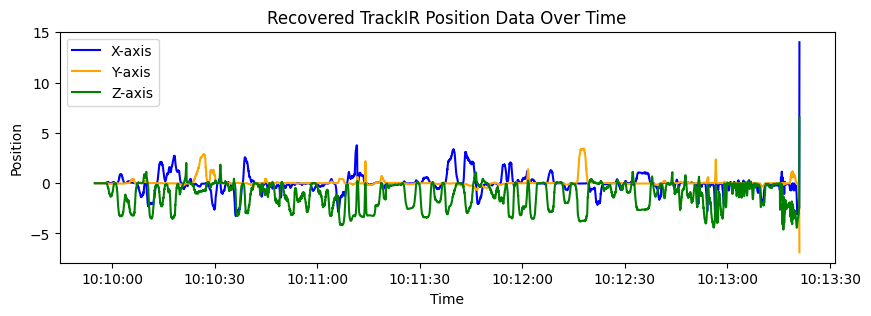

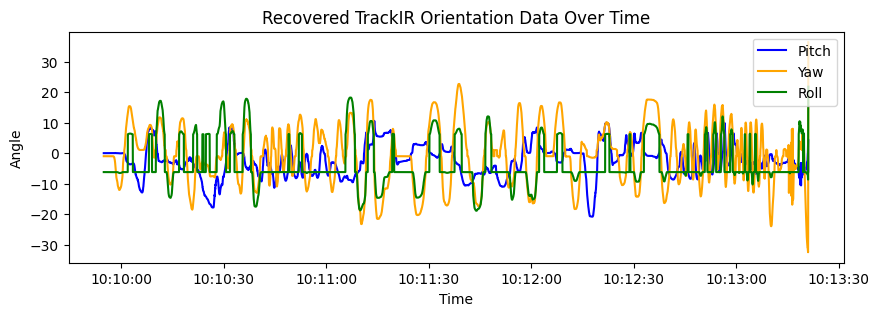

In [9]:
plt.figure(figsize=(10, 3))
plt.plot(trackir_df_recovered["Time"], trackir_df_recovered["X_Recovered"], label="X-axis", color="blue")
plt.plot(trackir_df_recovered["Time"], trackir_df_recovered["Y_Recovered"], label="Y-axis", color="orange")
plt.plot(trackir_df_recovered["Time"], trackir_df_recovered["Z_Recovered"], label="Z-axis", color="green")
plt.title("Recovered TrackIR Position Data Over Time")
plt.xlabel("Time")
plt.ylabel("Position")
plt.legend()
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(trackir_df_recovered["Time"], trackir_df_recovered["Pitch_Recovered"], label="Pitch", color="blue")
plt.plot(trackir_df_recovered["Time"], trackir_df_recovered["Yaw_Recovered"], label="Yaw", color="orange")
plt.plot(trackir_df_recovered["Time"], trackir_df_recovered["Roll_Recovered"], label="Roll", color="green")
plt.title("Recovered TrackIR Orientation Data Over Time")
plt.xlabel("Time")
plt.ylabel("Angle")
plt.legend()
plt.show()